# Functions to parse and clean data

### Imports

In [33]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 7.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.8 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 8.7 MB/s  0:00:00m0:00:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [34]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

## Parse data

In [22]:
# PARSING 
def parse_custom_csv(path):
    with open(path, "r") as f:
        lines = f.readlines()

    sections = {"META": [], "EVENTS": [], "METER": []}
    current = None

    for line in lines:
        line = line.strip()

        if line.startswith("#"):
            current = line.replace("#", "").strip() #define current section as the header
            continue

        if current and line:  # <-- FIX: skip empty lines
            sections[current].append(line)

    # META
    meta = {}
    for row in sections["META"]:
        k, v = row.split(",", 1)
        meta[k] = v

   # EVENTS
    header = sections["EVENTS"][0].split(",")
    data = [r.split(",") for r in sections["EVENTS"][1:]]
    events = pd.DataFrame(data, columns=header)

    # METER
    header = sections["METER"][0].split(",")
    data = [r.split(",") for r in sections["METER"][1:]]
    meter = pd.DataFrame(data, columns=header)

    return meta, events, meter

## Clean data

In [ ]:
# CLEANING
def clean_data(meta, events, meter, run_id):
    # Drop bad rows first
    events = events.dropna(subset=["payload_size", "tx_start", "rx_end"])

    # Convert types
    events["payload_size"] = events["payload_size"].astype(int)
    events["tx_start"] = pd.to_datetime(events["tx_start"])
    events["rx_end"] = pd.to_datetime(events["rx_end"])

    meter["timestamp"] = pd.to_datetime(meter["timestamp"])
    meter["v_shunt"] = meter["v_shunt"].astype(float)

    # Add run id
    events["run"] = run_id
    meter["run"] = run_id

    return meta, events, meter

## Align timings and label phases
So that time is standard ofver all runs

In [6]:
# TIME ALIGNING
def align_time(events, meter):
    t0 = events["tx_start"].min()

    events["t_start_s"] = (events["tx_start"] - t0).dt.total_seconds()
    events["t_end_s"] = (events["rx_end"] - t0).dt.total_seconds()

    meter["t_s"] = (meter["timestamp"] - t0).dt.total_seconds()

    return events, meter

In [25]:
# LABELING PHASES
def label_phases(events, meter):
    meter["phase"] = "idle"
    meter["payload_size"] = 0

    for _, row in events.iterrows():
        mask = (
            (meter["t_s"] >= row["t_start_s"]) &
            (meter["t_s"] <= row["t_end_s"]) # make sure both start and end are in the transmission window
        )
        
        meter.loc[mask, "phase"] = "tx" # label phase as tx
        meter.loc[mask, "payload_size"] = int(row["payload_size"])

    return meter

## Test the functions

In [26]:
file1 = Path("/Users/jude/Documents/GitHub/BTR/experiment/data/esp32/full_payload/esp32_full_payload_run01.csv")
meta1, events1, meter1 = parse_custom_csv(file1)
meta1, events1, meter1 = clean_data(meta1, events1, meter1, run_id=1)
events1, meter1 = align_time(events1, meter1)
meter1 = label_phases(events1, meter1)
print(events1.head())
print(meter1.head())


   run payload_size declared_size bytes_received                tx_start  \
0    1            1             1              1 2026-03-25 18:59:24.126   
1    1            2             2              2 2026-03-25 18:59:25.222   
2    1            4             4              4 2026-03-25 18:59:27.371   
3    1            8             8              8 2026-03-25 18:59:29.620   
4    1           16            16             16 2026-03-25 18:59:31.979   

                   rx_end complete verified  t_start_s  t_end_s  
0 2026-03-25 18:59:24.717     True     True      0.000    0.591  
1 2026-03-25 18:59:26.866     True     True      1.096    2.740  
2 2026-03-25 18:59:29.119     True     True      3.245    4.993  
3 2026-03-25 18:59:31.473     True     True      5.494    7.347  
4 2026-03-25 18:59:33.624     True     True      7.853    9.498  
                timestamp  v_shunt  run    t_s phase  payload_size
0 2026-03-25 18:59:24.130  0.10431    1  0.004    tx             1
1 2026-03-25 

Run on all files

In [27]:
all_meter = []
all_events = []

data_dir = Path("/Users/jude/Documents/GitHub/BTR/experiment/data/esp32/full_payload")

for i, file in enumerate(sorted(data_dir.glob("*.csv"))):
    meta, events, meter = parse_custom_csv(file)
    meta, events, meter = clean_data(meta, events, meter, run_id=i)

    events, meter = align_time(events, meter)
    meter = label_phases(events, meter)

    all_meter.append(meter)
    all_events.append(events)

meter_df = pd.concat(all_meter, ignore_index=True)
events_df = pd.concat(all_events, ignore_index=True)

# Stats and plots 

## Stats about voltage
nothing about power yet cause i dont know shunt resistance

In [30]:
summary = (
    meter_df
    .groupby("payload_size")["v_shunt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["sem"] = summary["std"] / np.sqrt(summary["count"])  # standard error
summary["ci95"] = 1.96 * summary["sem"]  # 95% confidence interval

print(summary)

    payload_size      mean       std  count       sem      ci95
0              0  0.106709  0.012536  31427  0.000071  0.000139
1              1  0.105872  0.010081   2079  0.000221  0.000433
2              2  0.108567  0.017586   5992  0.000227  0.000445
3              4  0.107042  0.011184   5836  0.000146  0.000287
4              8  0.107322  0.015903   6144  0.000203  0.000398
5             16  0.107171  0.011812   5836  0.000155  0.000303
6             32  0.107551  0.013212   5832  0.000173  0.000339
7             64  0.106596  0.011275   6086  0.000145  0.000283
8            128  0.108041  0.015495   5909  0.000202  0.000395
9            256  0.109236  0.017404   5962  0.000225  0.000442
10           512  0.106177  0.009782   6158  0.000125  0.000244
11          1024  0.106613  0.012277   6281  0.000155  0.000304
12          2048  0.108259  0.016010   6855  0.000193  0.000379
13          4096  0.106933  0.012133   7639  0.000139  0.000272
14          8192  0.107832  0.014293   9

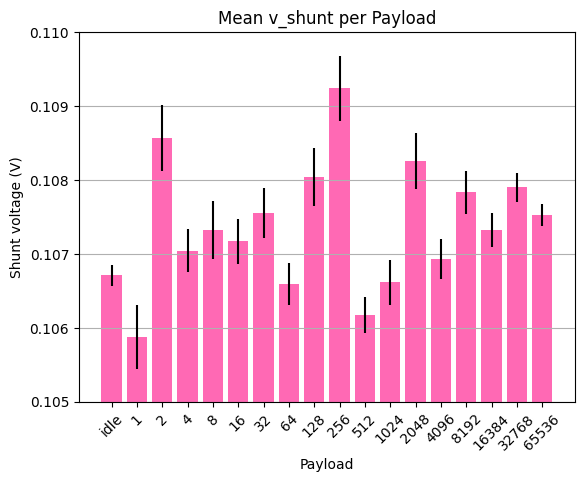

In [56]:
summary["payload_label"] = summary["payload_size"].astype(str)
summary.loc[summary["payload_size"] == 0, "payload_label"] = "idle"

plt.figure()
plt.bar(
    summary["payload_label"],
    summary["mean"],
    yerr=summary["ci95"],
    color='hotpink',
)

#cut off y axis at 0.1
plt.ylim(0.105, 0.11)
plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

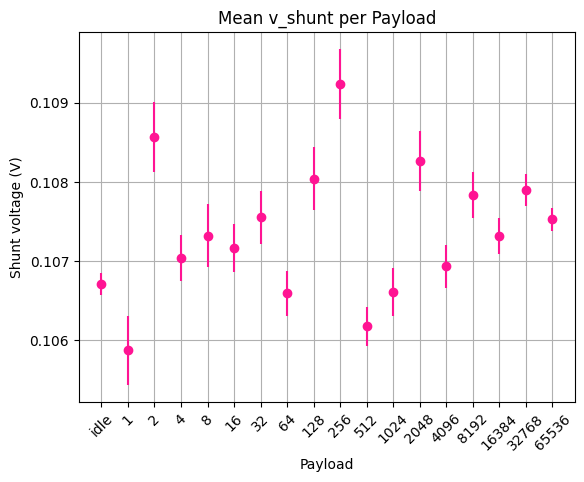

In [59]:
plt.errorbar(
    summary["payload_label"],
    summary["mean"],
    yerr=summary["ci95"],
    fmt='o',
    color= 'deeppink'
)

plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [37]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


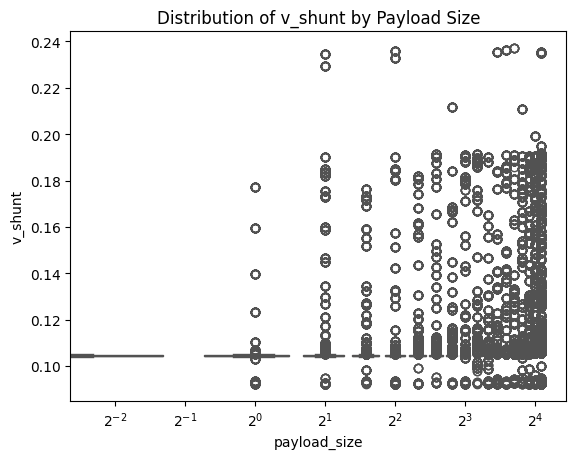

In [ ]:
import seaborn as sns

sns.boxplot(
    data=meter_df,
    x="payload_size",
    y="v_shunt",
    color='deeppink' #no color???
)

plt.xscale("log", base=2)
plt.title("Distribution of v_shunt by Payload Size")
plt.show()

## Stats about time

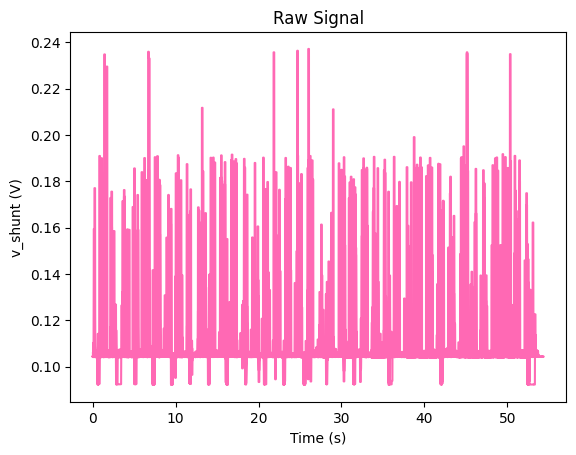

In [45]:
plt.plot(meter_df["t_s"], meter_df["v_shunt"], color='hotpink')
plt.xlabel("Time (s)")
plt.ylabel("v_shunt (V)")
plt.title("Raw Signal")
plt.show()

In [48]:
events_df["duration_s"] = (
    events_df["t_end_s"] - events_df["t_start_s"]
)

tx_summary = (
    events_df
    .groupby("payload_size")["duration_s"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
tx_summary["sem"] = tx_summary["std"] / np.sqrt(tx_summary["count"])  # standard error
tx_summary["ci95"] = 1.96 * tx_summary["sem"]  #95% confidence interval
print(tx_summary)

   payload_size       mean       std  count       sem      ci95
0             1   0.599062  0.067459     16  0.016865  0.033055
1          1024   1.811875  0.047165     16  0.011791  0.023111
2           128   1.716625  0.049628     16  0.012407  0.024318
3            16   1.687625  0.092863     16  0.023216  0.045503
4         16384   3.777188  0.130683     16  0.032671  0.064035
5             2   1.726562  0.173704     16  0.043426  0.085115
6          2048   1.974875  0.085262     16  0.021315  0.041778
7           256   1.714688  0.050624     16  0.012656  0.024806
8            32   1.695562  0.045910     16  0.011478  0.022496
9         32768   5.808125  0.101231     16  0.025308  0.049603
10            4   1.703875  0.163992     16  0.040998  0.080356
11         4096   2.194125  0.083696     16  0.020924  0.041011
12          512   1.796875  0.062177     16  0.015544  0.030467
13           64   1.758750  0.057245     16  0.014311  0.028050
14        65536  10.016875  0.230474    